In [1]:
import pandas as pd
import numpy as np
import torch

In [2]:
data = pd.read_csv("../../data/preprocessed/Event_traces.csv")

In [3]:
# convert string sequence to list sequence
data["Features"] = data["Features"].map(lambda x: x[1:-1].split(","))

# can map timeinterval with the operation ran
data["TimeInterval"] = data["TimeInterval"].map(lambda x: [float(i) for i in x[1:-1].split(",")])

In [4]:
data["Features"]

0         [E5, E22, E5, E5, E11, E11, E9, E9, E11, E9, E...
1         [E5, E5, E22, E5, E11, E9, E11, E9, E11, E9, E...
2         [E5, E22, E5, E5, E11, E9, E11, E9, E11, E9, E...
3         [E5, E22, E5, E5, E11, E9, E11, E9, E11, E9, E...
4         [E5, E5, E22, E5, E11, E9, E11, E9, E11, E9, E...
                                ...                        
575056    [E5, E22, E5, E5, E26, E11, E9, E11, E9, E11, ...
575057    [E5, E22, E5, E5, E11, E9, E26, E11, E9, E11, ...
575058    [E5, E5, E5, E22, E11, E9, E11, E9, E11, E9, E...
575059    [E5, E5, E5, E22, E11, E9, E11, E9, E11, E9, E...
575060    [E5, E5, E5, E22, E11, E9, E11, E9, E11, E9, E...
Name: Features, Length: 575061, dtype: object

In [5]:
from sklearn.preprocessing import OneHotEncoder

unique_features = data["Features"].map(lambda x: [i[1:] for i in x]).explode().unique().astype(np.int32)
unique_features.sort()

encoder = OneHotEncoder(sparse_output=False, dtype=np.float32)
encoded_features = encoder.fit(unique_features.reshape(-1, 1))

data["Features_Encoded"] = data["Features"].map(lambda x: encoder.transform([[int(i[1:])] for i in x]))

In [6]:
# clean data to reduce memory usage
data = data[["Features_Encoded", "TimeInterval", "Label"]]

In [7]:
data

,Features_Encoded,TimeInterval,Label
0,"[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Success
1,"[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Success
2,"[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",Fail
3,"[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Success
4,"[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 1.0, 48.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",Success
...,...,...,...
575056,"[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 1.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",Success
575057,"[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 14.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",Success
575058,"[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",Success
575059,"[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Success


In [8]:
# Maximum length of sequence is chosen as 50 based on the distribution of sequence lengths
# Sequences beyond this length are rare and has drippled effect on buiding even sequences
# (i.e., padding/truncating) for training. Most short or medium sequences from 1 -> 40 in
# length are padded up to 200s if this maximum length is not chosen.

MAX_LEN = 50 # maximum sequence length
ENCODED_DIMEN = data["Features_Encoded"].iloc[0].shape[1]  # for 'one-hot' encoding

# pad with zeros on the left to create even sequences for training
def left_pad_feature(seq, pad_len=MAX_LEN, encoded_dim=ENCODED_DIMEN):
    seq = np.stack(seq)  # shape: (L, 384)
    L = seq.shape[0]
    if L >= pad_len:
        return seq[-pad_len:]  # truncate if too long
    pad = np.zeros((pad_len - L, encoded_dim), dtype=seq.dtype)
    return np.vstack([pad, seq])

In [9]:
data["Features_Encoded_Padded"] = data["Features_Encoded"].map(left_pad_feature)

In [10]:
data = data[["Features_Encoded_Padded", "TimeInterval", "Label"]]

In [11]:
data["Features_Encoded_Padded"] = data["Features_Encoded_Padded"].map(lambda x: torch.from_numpy(x))

/var/folders/mt/4n2d597j4sl1j43rj4qnsn1w0000gn/T/ipykernel_4990/4010852748.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Features_Encoded_Padded"] = data["Features_Encoded_Padded"].map(lambda x: torch.from_numpy(x))


In [12]:
label_encoder = OneHotEncoder(sparse_output=False, dtype=np.float32)
encoded_labels = label_encoder.fit_transform(data["Label"].values.reshape(-1, 1))

In [13]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

In [14]:
success_mask = data["Label"] == "Success"
failed_mask = data["Label"] == "Fail"

In [15]:
X_success = torch.stack(data[success_mask]["Features_Encoded_Padded"].tolist())
X_fail = torch.stack(data[failed_mask]["Features_Encoded_Padded"].tolist())

In [16]:
y_success = torch.from_numpy(encoded_labels[success_mask])
y_fail = torch.from_numpy(encoded_labels[failed_mask])

In [17]:
N_success = len(X_success)
train_success_size = int(0.8 * N_success)
val_success_size = int(0.1 * N_success)
test_success_size = N_success - train_success_size - val_success_size

In [18]:
N_fail = len(X_fail)
val_fail_size = int(0.3 * N_fail)
test_fail_size = N_fail - val_fail_size

In [19]:
# Create a dataset of only features for training (Unsupervised)
success_dataset = torch.utils.data.TensorDataset(X_success)
train_subset, val_success_subset, test_success_subset = random_split(
    success_dataset, [train_success_size, val_success_size, test_success_size], 
    generator=torch.Generator().manual_seed(42)
)

fail_dataset = torch.utils.data.TensorDataset(X_fail)
val_fail_subset, test_fail_subset = random_split(
    fail_dataset, [val_fail_size, test_fail_size], 
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)

In [20]:
# For the Test Loader, we combine the remaining Success data + All Fail data
# We need (X, y) here to evaluate anomaly detection performance
test_success_indices = test_success_subset.indices
X_test_success = X_success[test_success_indices]
y_test_success = y_success[test_success_indices]

val_success_indices = val_success_subset.indices
X_val_success = X_success[val_success_indices]
y_val_success = y_success[val_success_indices]

test_fail_indices = test_fail_subset.indices
X_test_fail = X_fail[test_fail_indices]
y_test_fail = y_fail[test_fail_indices]

val_fail_indices = val_fail_subset.indices
X_val_fail = X_fail[val_fail_indices]
y_val_fail = y_fail[val_fail_indices]

X_test = torch.cat([X_test_success, X_test_fail])
y_test = torch.cat([y_test_success, y_test_fail])

X_val = torch.cat([X_val_success, X_val_fail])
y_val = torch.cat([y_val_success, y_val_fail])

test_dataset = torch.utils.data.TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

val_dataset = torch.utils.data.TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [21]:
print(y_val_success.size(), y_val_fail.size())
print(y_test_success.size(), y_test_fail.size())

torch.Size([55822, 2]) torch.Size([5051, 2])
torch.Size([55823, 2]) torch.Size([11787, 2])


In [22]:
print(f"Training samples (Success only): {len(train_subset)}")
print(f"Test samples (Mixed): {len(test_dataset)}")
print(f"Validation samples (Mixed): {len(val_dataset)}")

Training samples (Success only): 446578
Test samples (Mixed): 67610
Validation samples (Mixed): 60873


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LSTM_VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, seq_len):
        super(LSTM_VAE, self).__init__()
        self.seq_len = seq_len
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim

        # --- Encoder ---
        # Input: (batch_size, seq_len, input_dim)
        self.encoder_lstm = nn.LSTM(input_dim, hidden_dim, bidirectional=False, batch_first=True)
        # Map final hidden state to latent space parameters
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # --- Decoder ---
        # Map latent vector z back to hidden state dimension
        self.decoder_input = nn.Linear(latent_dim, hidden_dim)
        self.decoder_lstm = nn.LSTM(hidden_dim, hidden_dim, bidirectional=False, batch_first=True)
        # Map LSTM output to original input dimension
        self.fc_out = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        # Pass through LSTM
        _, (h_n, _) = self.encoder_lstm(x)
        # h_n shape: (1, batch_size, hidden_dim) -> squeeze to (batch_size, hidden_dim)
        h = h_n.squeeze(0)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)  # (batch_size, hidden_dim)
        
        # Repeat the vector to form a sequence for the decoder LSTM
        # Shape becomes: (batch_size, seq_len, hidden_dim)
        h_seq = h.unsqueeze(1).repeat(1, self.seq_len, 1)
        
        out, _ = self.decoder_lstm(h_seq)
        return self.fc_out(out) # (batch_size, seq_len, input_dim)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar


In [24]:
def vae_loss_function(recon_x, x, mu, logvar):
    # Reconstruction loss (MSE)
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    # KL Divergence
    # -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + kld_loss


In [25]:
def vae_beta_loss_function(recon_x, x, mu, logvar, beta=0.1):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    # Scale KLD by beta
    return recon_loss + (beta * kld_loss)

In [26]:
# --- Hyperparameters ---
INPUT_DIM = ENCODED_DIMEN
HIDDEN_DIM = 32
LATENT_DIM = 16
SEQ_LEN = MAX_LEN
LEARNING_RATE = 3e-4
EPOCHS = 10

# --- Initialize Model ---
vae = LSTM_VAE(INPUT_DIM, HIDDEN_DIM, LATENT_DIM, SEQ_LEN)
optimizer_vae = torch.optim.Adam(vae.parameters(), lr=LEARNING_RATE)

In [27]:
from tqdm import tqdm
print("Starting VAE Training...")
vae.train()
for epoch in range(EPOCHS):
    train_loss = 0
    # Updated unpacking: train_loader now yields single-element tuples (features,)
    for batch_idx, (data_batch,) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
        optimizer_vae.zero_grad()
        
        # Forward pass
        recon_batch, mu, logvar = vae(data_batch)
        
        # Loss calculation (Input is Target)
        loss = vae_beta_loss_function(recon_batch, data_batch, mu, logvar, beta=0.1)
        loss.backward()
        
        train_loss += loss.item()
        optimizer_vae.step()
    
    avg_loss = train_loss / len(train_loader.dataset)
    print(f'Epoch {epoch+1}, Average Loss: {avg_loss:.4f}')

Starting VAE Training...


Epoch 1: 100%|██████████| 13956/13956 [01:52<00:00, 123.89it/s]


Epoch 1, Average Loss: 11.3000


Epoch 2: 100%|██████████| 13956/13956 [01:55<00:00, 120.89it/s]


Epoch 2, Average Loss: 7.9981


...

Epoch 8, Average Loss: 4.1387


Epoch 9: 100%|██████████| 13956/13956 [01:53<00:00, 122.73it/s]


Epoch 9, Average Loss: 3.9659


Epoch 10: 100%|██████████| 13956/13956 [01:53<00:00, 123.14it/s]

Epoch 10, Average Loss: 3.8221


In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [82]:
from sklearn.metrics import roc_curve, auc

vae.eval()
reconstruction_errors = []
true_labels = []

print("Evaluating on Val Set...")

with torch.no_grad():
    for data_batch, labels_batch in tqdm(val_loader):
        # Forward pass
        recon_batch, mu, logvar = vae(data_batch)
        
        # Calculate reconstruction error per sample (MSE)
        # reduction='none' keeps the shape (batch, seq_len, input_dim)
        loss = F.mse_loss(recon_batch, data_batch, reduction='none')
        
        # Sum errors over sequence and feature dimensions to get a single scalar score per sample
        # shape: (batch_size,)
        sample_losses = loss.sum(dim=[1, 2])
        
        reconstruction_errors.extend(sample_losses.cpu().numpy())
        
        # Convert one-hot labels to class indices
        true_labels.extend(labels_batch.argmax(dim=1).cpu().numpy())

reconstruction_errors = np.array(reconstruction_errors)
true_labels = np.array(true_labels)

# --- Thresholding Strategy ---
# We assume 'Fail' is the anomaly class.
# We need to map the class indices to names to know which is which.
class_names = label_encoder.categories_[0]
print(f"Class mapping: {dict(enumerate(class_names))}")

fail_idx = np.where(class_names == 'Fail')[0][0]
success_idx = np.where(class_names == 'Success')[0][0]

# Create binary labels for ROC calculation: 1 for Anomaly (Fail), 0 for Normal (Success)
binary_true_labels = (true_labels == fail_idx).astype(int)

# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(binary_true_labels, reconstruction_errors)
roc_auc = auc(fpr, tpr)

# Find Optimal Threshold (Youden's J statistic: max(TPR - FPR))
# This finds the point on the ROC curve closest to the top-left corner
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"ROC AUC: {roc_auc:.4f}")
print(f"Optimal Reconstruction Threshold: {optimal_threshold:.4f}")

# --- Generate Predictions ---
# If Error > Threshold -> Predict Anomaly (Fail)
# If Error <= Threshold -> Predict Normal (Success)
binary_preds = (reconstruction_errors > optimal_threshold).astype(int)

# Map binary predictions back to original class indices for the report
all_preds = np.zeros_like(true_labels)
all_preds[binary_preds == 1] = fail_idx
all_preds[binary_preds == 0] = success_idx

all_targets = true_labels

Evaluating on Val Set...


100%|██████████| 1903/1903 [00:05<00:00, 348.44it/s]

Class mapping: {0: 'Fail', 1: 'Success'}
ROC AUC: 0.9370
Optimal Reconstruction Threshold: 6.1666


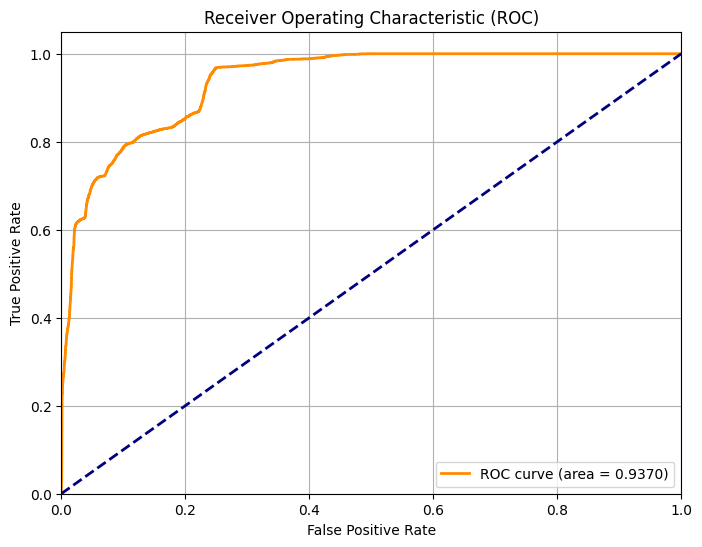

In [83]:
# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line (random guess)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [84]:
from sklearn.metrics import classification_report

# Get readable class names from the label encoder
# We need to ensure the order matches the indices (0, 1)
class_names_list = [str(c) for c in label_encoder.categories_[0]]

print("Classification Report:")
print(classification_report(all_targets, all_preds, target_names=class_names_list, digits=4))

Classification Report:
              precision    recall  f1-score   support

        Fail     0.2599    0.9675    0.4097      5051
     Success     0.9961    0.7507    0.8561     55822

    accuracy                         0.7687     60873
   macro avg     0.6280    0.8591    0.6329     60873
weighted avg     0.9350    0.7687    0.8191     60873



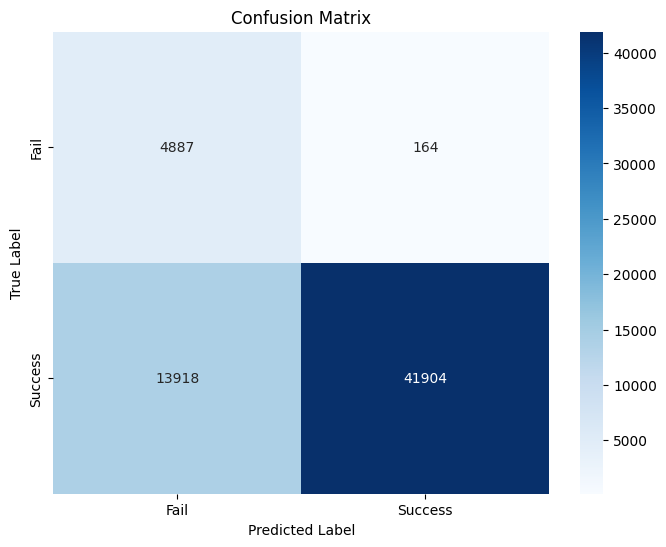

In [85]:
# --- Visual Evaluation: Confusion Matrix ---
cm = confusion_matrix(all_targets, all_preds)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [86]:
from sklearn.metrics import accuracy_score

per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

for i, class_name in enumerate(class_names_list):
    print(f"Accuracy for {class_name}: {per_class_accuracy[i]:.4f}")

print("Total Accuracy:", accuracy_score(all_targets, all_preds))

Accuracy for Fail: 0.9675
Accuracy for Success: 0.7507
Total Accuracy: 0.7686659109950225


In [87]:
vae.eval()
reconstruction_errors = []
true_labels = []

print("Evaluating on Test Set...")

with torch.no_grad():
    for data_batch, labels_batch in tqdm(test_loader):
        # Forward pass
        recon_batch, mu, logvar = vae(data_batch)
        
        # Calculate reconstruction error per sample (MSE)
        # reduction='none' keeps the shape (batch, seq_len, input_dim)
        loss = F.mse_loss(recon_batch, data_batch, reduction='none')
        
        # Sum errors over sequence and feature dimensions to get a single scalar score per sample
        # shape: (batch_size,)
        sample_losses = loss.sum(dim=[1, 2])
        
        reconstruction_errors.extend(sample_losses.cpu().numpy())
        
        # Convert one-hot labels to class indices
        true_labels.extend(labels_batch.argmax(dim=1).cpu().numpy())

reconstruction_errors = np.array(reconstruction_errors)
true_labels = np.array(true_labels)

# --- Thresholding Strategy ---
# We assume 'Fail' is the anomaly class.
# We need to map the class indices to names to know which is which.
class_names = label_encoder.categories_[0]
print(f"Class mapping: {dict(enumerate(class_names))}")

fail_idx = np.where(class_names == 'Fail')[0][0]
success_idx = np.where(class_names == 'Success')[0][0]

# Create binary labels for ROC calculation: 1 for Anomaly (Fail), 0 for Normal (Success)
binary_true_labels = (true_labels == fail_idx).astype(int)

# --- Generate Predictions ---
# If Error > Threshold -> Predict Anomaly (Fail)
# If Error <= Threshold -> Predict Normal (Success)
binary_preds = (reconstruction_errors > optimal_threshold).astype(int)

# Map binary predictions back to original class indices for the report
all_preds = np.zeros_like(true_labels)
all_preds[binary_preds == 1] = fail_idx
all_preds[binary_preds == 0] = success_idx

all_targets = true_labels

Evaluating on Test Set...


100%|██████████| 2113/2113 [00:06<00:00, 340.13it/s]

Class mapping: {0: 'Fail', 1: 'Success'}


In [88]:
# Get readable class names from the label encoder
# We need to ensure the order matches the indices (0, 1)
class_names_list = [str(c) for c in label_encoder.categories_[0]]

print("Classification Report:")
print(classification_report(all_targets, all_preds, target_names=class_names_list, digits=4))

Classification Report:
              precision    recall  f1-score   support

        Fail     0.4519    0.9673    0.6160     11787
     Success     0.9909    0.7523    0.8552     55823

    accuracy                         0.7898     67610
   macro avg     0.7214    0.8598    0.7356     67610
weighted avg     0.8969    0.7898    0.8135     67610



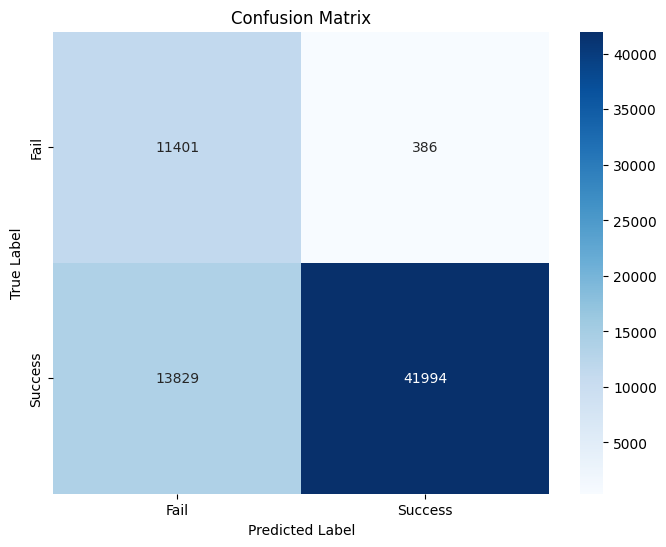

In [89]:
# --- Visual Evaluation: Confusion Matrix ---
cm = confusion_matrix(all_targets, all_preds)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score

per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

for i, class_name in enumerate(class_names_list):
    print(f"Accuracy for {class_name}: {per_class_accuracy[i]:.4f}")

print("Total Accuracy:", accuracy_score(all_targets, all_preds))

Accuracy for Fail: 0.9673
Accuracy for Success: 0.7523
Total Accuracy: 0.7897500369767786


In [91]:
torch.save(vae.state_dict(), "../../saved_models/lstm_vae_one_hot_encoding.pth")